In [1]:
import os

from sklearn.metrics import confusion_matrix, classification_report

os.environ['TF_ENABLE_ONEDNN_OPTS']= '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import keras as kr
from keras.callbacks import EarlyStopping

from sklearn.utils.class_weight import compute_class_weight



In [2]:
set_date_antrenare = kr.utils.image_dataset_from_directory(
    'D:/Licenta/DataSetOrganized/data/train',
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)

set_date_validare = kr.utils.image_dataset_from_directory(
    'D:/Licenta/DataSetOrganized/data/validation',
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)

set_date_testare = kr.utils.image_dataset_from_directory(
    'D:/Licenta/DataSetOrganized/data/test',
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)


Found 3000 files belonging to 5 classes.
Found 600 files belonging to 5 classes.
Found 400 files belonging to 5 classes.


In [4]:
model_data_augumentation = kr.Sequential([kr.layers.RandomFlip("horizontal_and_vertical"),kr.layers.RandomBrightness(0.1),kr.layers.RandomContrast(0.1)],name="augumentare_date")

In [5]:
def squeeze_excite_block(tensor,ratio=16):
    filters = tensor.shape[-1]
    s_e_b = kr.layers.GlobalAvgPool2D()(tensor)
    s_e_b = kr.layers.Dense(filters // ratio,activation = 'relu' , kernel_initializer='he_normal')(s_e_b)
    s_e_b = kr.layers.Dense(filters,activation='sigmoid')(s_e_b)
    s_e_b = kr.layers.Reshape((1,1,filters))(s_e_b)
    return kr.layers.Multiply()([tensor,s_e_b])

In [6]:
inputs = kr.layers.Input(shape=(256,256,3))


x = model_data_augumentation(inputs)
x =  kr.layers.Rescaling(1./255)(x)

x = kr.layers.Conv2D(64,3,padding ='same',kernel_initializer='he_normal')(x)
x = kr.layers.BatchNormalization()(x)
x = kr.layers.Activation('relu')(x)
x = squeeze_excite_block(x)
x = kr.layers.MaxPooling2D(2,2)(x)

x = kr.layers.Conv2D(128,3,padding ='same',kernel_initializer='he_normal')(x)
x = kr.layers.BatchNormalization()(x)
x = kr.layers.Activation('relu')(x)
x = squeeze_excite_block(x)
x = kr.layers.MaxPooling2D(2,2)(x)


x = kr.layers.Conv2D(256,3,padding ='same',kernel_initializer='he_normal')(x)
x = kr.layers.BatchNormalization()(x)
x = kr.layers.Activation('relu')(x)
x = squeeze_excite_block(x)
x = kr.layers.MaxPooling2D(2,2)(x)


x = kr.layers.GlobalAveragePooling2D()(x)
x = kr.layers.Dense(256, activation='relu')(x)
x = kr.layers.Dropout(0.5)(x)
outputs = kr.layers.Dense(5, activation='softmax')(x)

model_antrenare = kr.models.Model(inputs = inputs, outputs = outputs)

optimizator = tf.keras.optimizers.AdamW(learning_rate=0.0002,weight_decay=1e-4)

model_antrenare.compile(optimizer=optimizator, loss='sparse_categorical_crossentropy',metrics=['accuracy'])

reduce_lr = kr.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,patience=10,min_lr=1e-6,verbose=1)

early_stop = kr.callbacks.EarlyStopping(monitor='val_loss', patience=20, verbose=1,restore_best_weights=True,start_from_epoch=5)

model_antrenare.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augumentare_date    │ (None, 256, 256,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 256, 256,  │          0 │ augumentare_date… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ rescaling[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ activation[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │        260 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        320 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 64)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 256, 256,  │          0 │ activation[0][0], │
│                     │ 64)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ multiply[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ activation_1[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8)         │      1,032 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │      1,152 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 450,913 (1.72 MB)

 Trainable params: 450,017 (1.72 MB)

 Non-trainable params: 896 (3.50 KB)

In [7]:
y_train = np.concatenate([y for x,y in set_date_antrenare],axis=0)
clase_unice = np.unique(y_train)

class_weights_array = compute_class_weight(class_weight='balanced',classes=clase_unice,y=y_train)
class_weights_dict = dict(zip(clase_unice,class_weights_array))

print(class_weights_dict)

{np.int32(0): np.float64(1.0), np.int32(1): np.float64(1.0), np.int32(2): np.float64(1.0), np.int32(3): np.float64(1.0), np.int32(4): np.float64(1.0)}


In [8]:
model_antrenare_istoric = model_antrenare.fit(x=set_date_antrenare,validation_data = set_date_validare,epochs=60,callbacks=[early_stop,reduce_lr],class_weight=class_weights_dict)

Epoch 1/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 327s 3s/step - accuracy: 0.5427 - loss: 1.1569 - val_accuracy: 0.2067 - val_loss: 1.6391 - learning_rate: 2.0000e-04
Epoch 2/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 326s 3s/step - accuracy: 0.6153 - loss: 0.9749 - val_accuracy: 0.2067 - val_loss: 2.0791 - learning_rate: 2.0000e-04
Epoch 3/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 325s 3s/step - accuracy: 0.6400 - loss: 0.9111 - val_accuracy: 0.2433 - val_loss: 1.9370 - learning_rate: 2.0000e-04
Epoch 4/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 326s 3s/step - accuracy: 0.6650 - loss: 0.8557 - val_accuracy: 0.3717 - val_loss: 1.3569 - learning_rate: 2.0000e-04
Epoch 5/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 326s 3s/step - accuracy: 0.6940 - loss: 0.7922 - val_accuracy: 0.5050 - val_loss: 1.0132 - learning_rate: 2.0000e-04
Epoch 6/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 327s 3s/step - accuracy: 0.6950 - loss: 0.7605 - val_accuracy: 0.5617 - val_loss: 0.9558 - learning_rate: 2.0000e-04
Epoch 7/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 329s 3s/step - accuracy: 0.7187 

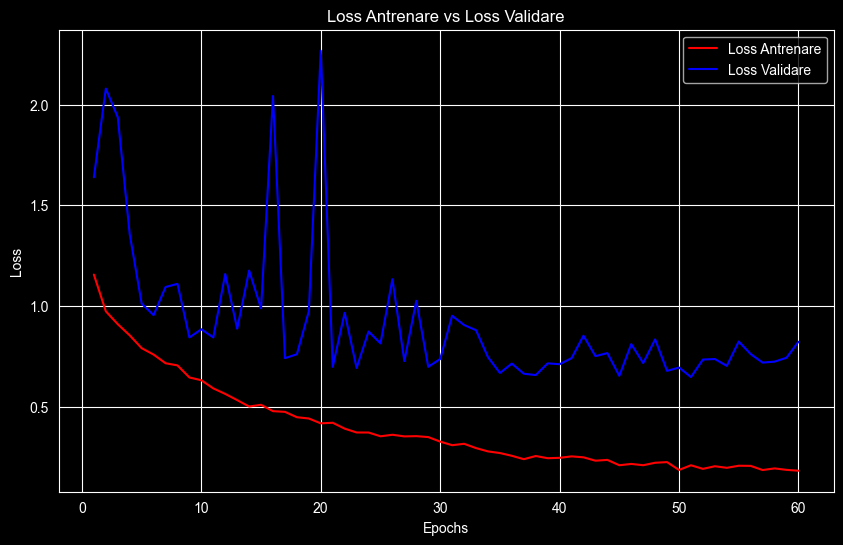

In [9]:
loss = model_antrenare_istoric.history['loss']
val_loss = model_antrenare_istoric.history['val_loss']
epochs = range(1, len(loss) + 1)


plt.figure(figsize = (10,6))
plt.plot(epochs, loss, 'r', label='Loss Antrenare')
plt.plot(epochs, val_loss, 'b', label='Loss Validare')
plt.title('Loss Antrenare vs Loss Validare')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

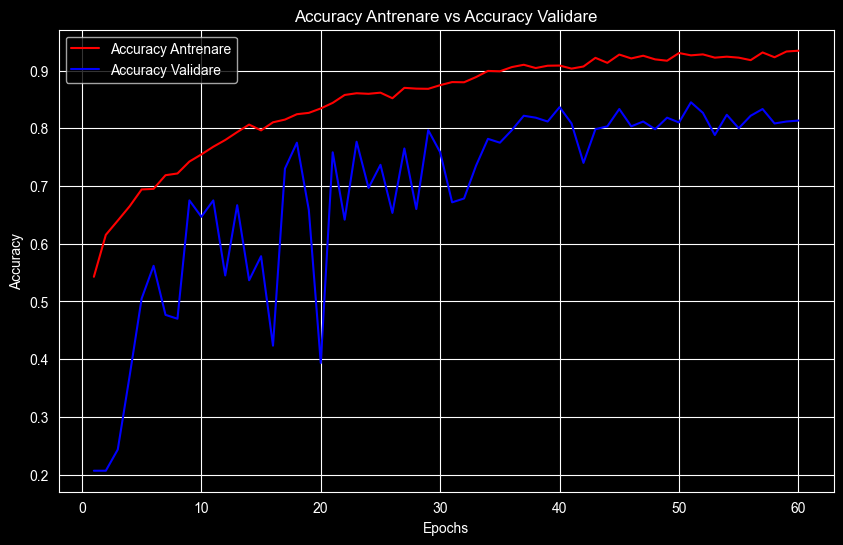

In [10]:
accuracy = model_antrenare_istoric.history['accuracy']
val_accuracy = model_antrenare_istoric.history['val_accuracy']
epochs = range(1, len(accuracy) + 1)


plt.figure(figsize = (10,6))
plt.plot(epochs, accuracy, 'r', label='Accuracy Antrenare')
plt.plot(epochs, val_accuracy, 'b', label='Accuracy Validare')
plt.title('Accuracy Antrenare vs Accuracy Validare')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

In [11]:
test_loss,test_accuracy = model_antrenare.evaluate(set_date_testare)
print(test_loss)
print(test_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 370ms/step - accuracy: 0.8550 - loss: 0.5074
0.507449209690094
0.8550000190734863


In [12]:
val_accuracy,val_loss = model_antrenare.evaluate(set_date_validare)
print(val_accuracy)
print(val_loss)

19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 377ms/step - accuracy: 0.8450 - loss: 0.6491
0.6490792632102966
0.8450000286102295


13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 377ms/step


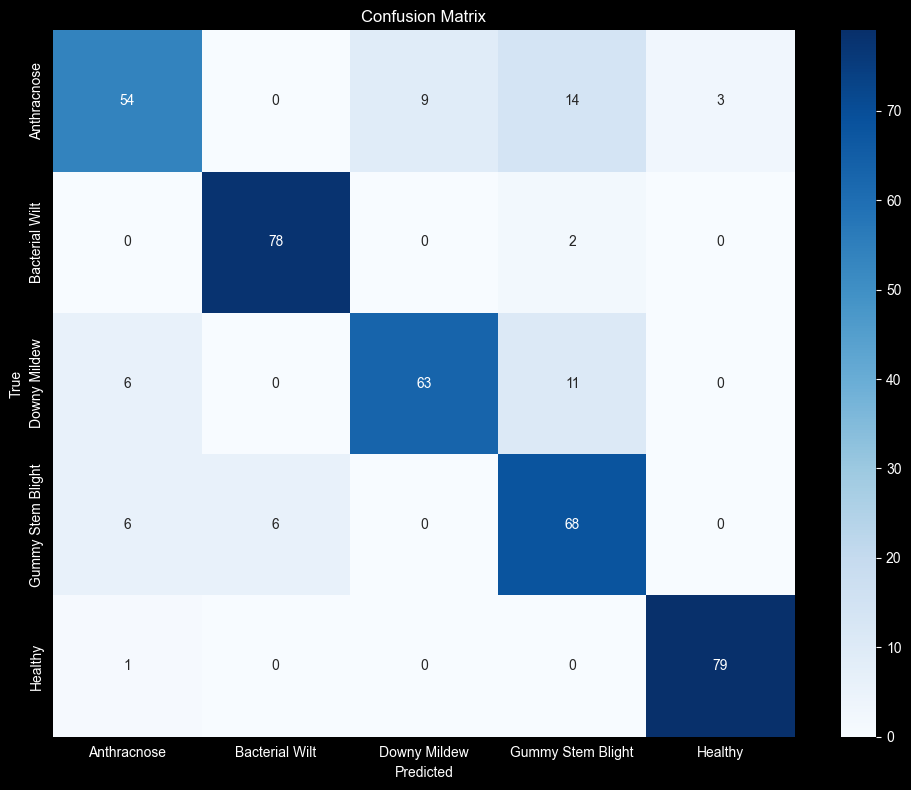

                   precision    recall  f1-score   support

      Anthracnose       0.81      0.68      0.73        80
   Bacterial Wilt       0.93      0.97      0.95        80
     Downy Mildew       0.88      0.79      0.83        80
Gummy Stem Blight       0.72      0.85      0.78        80
          Healthy       0.96      0.99      0.98        80

         accuracy                           0.85       400
        macro avg       0.86      0.86      0.85       400
     weighted avg       0.86      0.85      0.85       400



In [13]:
y_corect = np.concatenate([y for x,y in set_date_testare],axis=0)
prediction = model_antrenare.predict(set_date_testare)
y_prediction = np.argmax(prediction,axis=1)

class_name = set_date_testare.class_names


cm = confusion_matrix(y_corect,y_prediction)


plt.figure(figsize = (10,8))
sns.heatmap(cm,annot=True,fmt='g',cmap='Blues',xticklabels=class_name,yticklabels=class_name)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()


print(classification_report(y_corect,y_prediction,target_names=class_name))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


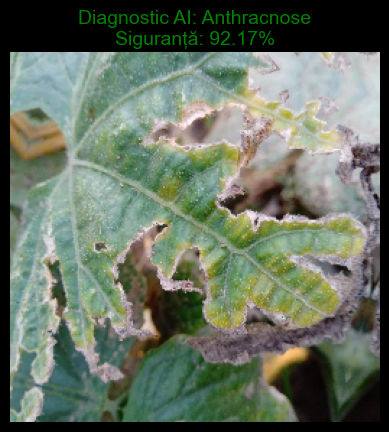

In [15]:
cale_poze = r'D:\Licenta\DataSetOrganized\data\train\Anthracnose\Anthracnose (8).jpg'
clase = ['Anthracnose', 'Bacterial Wilt', 'Downy Mildew', 'Gummy Stem Blight', 'Healthy']
imagine_test = kr.utils.load_img(cale_poze, target_size=(256, 256))
imagine_array = kr.utils.img_to_array(imagine_test)
imagine_array = np.expand_dims(imagine_array, axis=0)

predictii = model_antrenare.predict(imagine_array)
index = np.argmax(predictii[0])
boala_detectata = clase[index]
siguranta = predictii[0][index] * 100

plt.imshow(imagine_test)
plt.title(f"Diagnostic AI: {boala_detectata}\nSiguranță: {siguranta:.2f}%", fontsize=14, color='green')
plt.axis('off')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


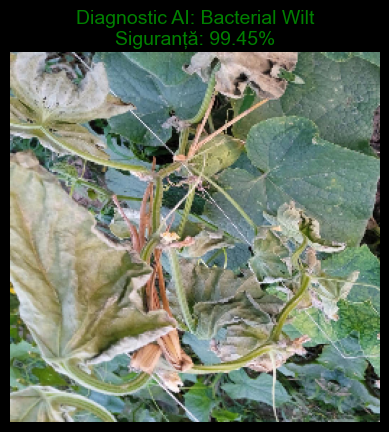

In [16]:
cale_poze = r'D:\Licenta\DataSetOrganized\data\train\Bacterial Wilt\Bacterial Wilt (6).jpg'
clase = ['Anthracnose', 'Bacterial Wilt', 'Downy Mildew', 'Gummy Stem Blight', 'Healthy']
imagine_test = kr.utils.load_img(cale_poze, target_size=(256, 256))
imagine_array = kr.utils.img_to_array(imagine_test)
imagine_array = np.expand_dims(imagine_array, axis=0)

predictii = model_antrenare.predict(imagine_array)
index = np.argmax(predictii[0])
boala_detectata = clase[index]
siguranta = predictii[0][index] * 100

plt.imshow(imagine_test)
plt.title(f"Diagnostic AI: {boala_detectata}\nSiguranță: {siguranta:.2f}%", fontsize=14, color='green')
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


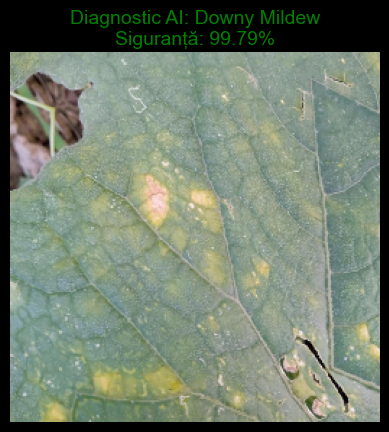

In [17]:
cale_poze = r'D:\Licenta\DataSetOrganized\data\validation\Downy Mildew\Downy Mildew (639).jpg'
clase = ['Anthracnose', 'Bacterial Wilt', 'Downy Mildew', 'Gummy Stem Blight', 'Healthy']
imagine_test = kr.utils.load_img(cale_poze, target_size=(256, 256))
imagine_array = kr.utils.img_to_array(imagine_test)
imagine_array = np.expand_dims(imagine_array, axis=0)

predictii = model_antrenare.predict(imagine_array)
index = np.argmax(predictii[0])
boala_detectata = clase[index]
siguranta = predictii[0][index] * 100

plt.imshow(imagine_test)
plt.title(f"Diagnostic AI: {boala_detectata}\nSiguranță: {siguranta:.2f}%", fontsize=14, color='green')
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


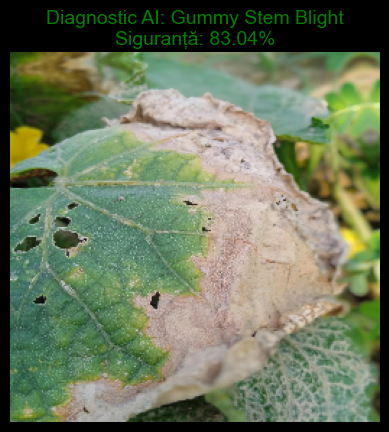

In [18]:
cale_poze = r'D:\Licenta\DataSetOrganized\data\train\Gummy Stem Blight\Gummy Stem Blight (13).jpg'
clase = ['Anthracnose', 'Bacterial Wilt', 'Downy Mildew', 'Gummy Stem Blight', 'Healthy']
imagine_test = kr.utils.load_img(cale_poze, target_size=(256, 256))
imagine_array = kr.utils.img_to_array(imagine_test)
imagine_array = np.expand_dims(imagine_array, axis=0)

predictii = model_antrenare.predict(imagine_array)
index = np.argmax(predictii[0])
boala_detectata = clase[index]
siguranta = predictii[0][index] * 100

plt.imshow(imagine_test)
plt.title(f"Diagnostic AI: {boala_detectata}\nSiguranță: {siguranta:.2f}%", fontsize=14, color='green')
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


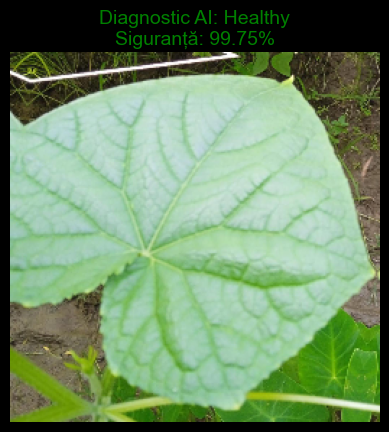

In [19]:
cale_poze = r'D:\Licenta\DataSetOrganized\data\train\Healthy\Fresh Leaf (88).jpg'
clase = ['Anthracnose', 'Bacterial Wilt', 'Downy Mildew', 'Gummy Stem Blight', 'Healthy']
imagine_test = kr.utils.load_img(cale_poze, target_size=(256, 256))
imagine_array = kr.utils.img_to_array(imagine_test)
imagine_array = np.expand_dims(imagine_array, axis=0)

predictii = model_antrenare.predict(imagine_array)
index = np.argmax(predictii[0])
boala_detectata = clase[index]
siguranta = predictii[0][index] * 100

plt.imshow(imagine_test)
plt.title(f"Diagnostic AI: {boala_detectata}\nSiguranță: {siguranta:.2f}%", fontsize=14, color='green')
plt.axis('off')
plt.show()

In [20]:
model_antrenare.save('model_antrenare_licenta.keras')